## **Project:** AB TESTING ON LOAN INTEREST RATE

In [6]:

#UNDERSTANDING THE PROBLEM
A finance company wants to know:
-> if we reduce the loan interest rate, will more people accept the loan?

therefore we test two groups
Group     Interest rate
 A          15%
 B          12%

# Objective:
Determine whether adjusting the loan interst rate improves customers uptake, while still meeting company profitability metries.

# Population:
1000, potential borrowers(randomly sampled the companys customer base).
# Group A(control):
500 customers offered the current loan rate strategy(15% annual interest, standard fee).

# Group B(treatment):
500 customers offered a modified loan rate strategy(12% annual interest, reduced processing fee or more flexible repayment terms)

# Metrics To Track
1. Engagement Rate: Percent of customers who show interest.
2. conversion rate: Percent of customers who actually take the loan
3. Average loan size: How much customers borrow under each strategy.
4. Defult Risk indicators: Early repayment behavior or missed payments.
5. Profitability: Net margin per loan after costs.

# HYPOTHESIS:
-> Ho (Null hypothesis): There is no significant difference in loan uptake between group A and group B.
-> H1 (Alternative hypothesis): Group B modified loan rate strategy leads to higher uptake and engagement.

# Experimental Outcome(Hypothetical)

Metric	                Group A (Control)	  Group B (Treatment)
Engagement Rate:        20% (100/500)	      35% (175/500)
Conversion Rate:        10% (50/500)	      22% (110/500)
Avg Loan Size:	        ₦500,000	          ₦450,000
Default Risk (early):	5%	                  6%
Profit Margin/Loan: 	₦75,000               ₦60,000



SyntaxError: invalid character '₦' (U+20A6) (4194130000.py, line 37)

conversion Rate A: 11.0 %
conversion Rate B: 20.6 %
total profit A: 41250000.0
total profit B: 6180000.0
Group B strategy generates more profit.


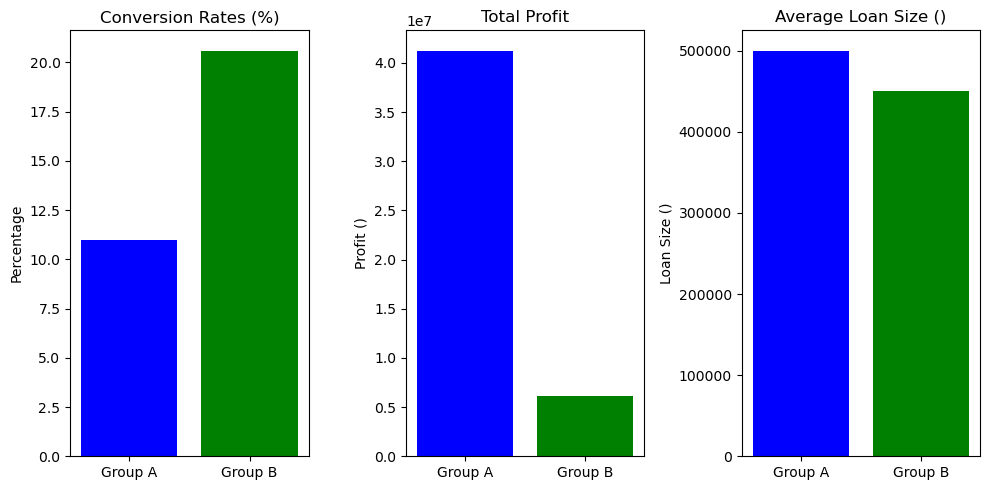

z statistic: -4.161564672544211
p-value: 3.160744559087088e-05
The difference between group A and group B is statistically significant.


In [1]:
#IMPLEMENTATION

import numpy as np
import pandas as pd

np.random.seed(42)
group_A = np.random.choice([0,1], size = 500, p=[0.9,0.1])
group_B = np.random.choice([0,1], size = 500, p=[0.78,0.22])
df = pd.DataFrame({"Group": ["A"]*500 + ["B"]*500,"converted": np.concatenate([group_A, group_B])})
conversion_A = df[df.Group == "A"].converted.mean()
conversion_B = df[df.Group == "B"].converted.mean()

#Assumptions about loan size and margin
avg_loan_A, margin_A = 500000,750000
avg_loan_B, margin_B = 450000,60000

#Calculate total profit
profit_A = (conversion_A * 500) * margin_A
profit_B = (conversion_B * 500) * margin_B

print("conversion Rate A:",round(conversion_A * 100,2),"%")
print("conversion Rate B:",round(conversion_B * 100,2),"%")
print("total profit A:", profit_A)
print("total profit B:", profit_B)

import matplotlib.pyplot as plt

labels = ['Group A', 'Group B']
conversion_rates = [conversion_A*100, conversion_B*100]
profits = [profit_A, profit_B]

fig, ax = plt.subplots(1,3, figsize=(10,5))

# Conversion Rate Bar Chart
ax[0].bar(labels, conversion_rates, color=['blue','green'])
ax[0].set_title("Conversion Rates (%)")
ax[0].set_ylabel("Percentage")

# Profit total Bar Chart
labels = ['Group A', 'Group B']
profits = [profit_A, profit_B]
ax[1].bar(labels, profits, color=['blue','green'])
ax[1].set_title("Total Profit")
ax[1].set_ylabel("Profit ()")

if profit_B > profit_A:
    print("Group B strategy generates more profit.")
else:
    print("Group B strategy generates more profit.")

# Chart 3: (Optional extra visualization, e.g. average loan size)
avg_loans = [500000, 450000]
ax[2].bar(labels, avg_loans, color=['blue','green'])
ax[2].set_title("Average Loan Size ()")
ax[2].set_ylabel("Loan Size ()")

plt.tight_layout()
plt.show()

from statsmodels.stats.proportion import proportions_ztest
success_A = sum(group_A)
success_B = sum(group_B)

n_A = len(group_A)
n_B = len(group_B)

success = np.array([success_A, success_B])
total = np.array([n_A, n_B])

Z_stat, p_value = proportions_ztest(success, total)

print("z statistic:", Z_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("The difference between group A and group B is statistically significant.")
else:
    print("The difference is not statistically significant.")